In [1]:
import mit_utils
data = mit_utils.open_mds('../output/260413_171225',prefix='dync')
data

<xarray.Dataset> Size: 54GB
Dimensions:  (YC: 192, XC: 720, YG: 192, XG: 720, Zp1: 39, Z: 38, time: 429,
              Zl: 38, Zu: 38)
Coordinates:
  * XC       (XC) float32 3kB 112.0 112.2 112.5 112.8 ... 291.2 291.5 291.8
  * YC       (YC) float32 768B -23.5 -23.25 -23.0 -22.75 ... 23.75 24.0 24.25
  * XG       (XG) float32 3kB 111.9 112.1 112.4 112.6 ... 291.1 291.4 291.6
  * YG       (YG) float32 768B -23.62 -23.38 -23.12 -22.88 ... 23.62 23.88 24.12
  * Z        (Z) float32 152B -2.85 -9.0 -16.1 ... -4.833e+03 -5.275e+03
  * Zp1      (Zp1) float32 156B 0.0 -5.7 -12.3 ... -5.051e+03 -5.499e+03
  * Zu       (Zu) float32 152B -5.7 -12.3 -19.9 ... -5.051e+03 -5.499e+03
  * Zl       (Zl) float32 152B 0.0 -5.7 -12.3 ... -4.616e+03 -5.051e+03
  * time     (time) datetime64[ns] 3kB 1990-02-15T22:30:00 ... 2025-10-17T04:...
Data variables: (12/34)
    rA       (YC, XC) >f4 553kB dask.array<chunksize=(192, 720), meta=np.ndarray>
    dxG      (YG, XC) >f4 553kB dask.array<chunksize=(192, 720), meta=np.ndarray>
    dyG      (YC, XG) >f4 553kB dask.array<chunksize=(192, 720), meta=np.ndarray>
    Depth    (YC, XC) >f4 553kB dask.array<chunksize=(192, 720), meta=np.ndarray>
    rAz      (YG, XG) >f4 553kB dask.array<chunksize=(192, 720), meta=np.ndarray>
    dxC      (YC, XG) >f4 553kB dask.array<chunksize=(192, 720), meta=np.ndarray>
    ...       ...
    UVEL     (time, Z, YC, XG) float32 9GB dask.array<chunksize=(1, 38, 192, 720), meta=np.ndarray>
    VVEL     (time, Z, YG, XC) float32 9GB dask.array<chunksize=(1, 38, 192, 720), meta=np.ndarray>
    WVEL     (time, Zl, YC, XC) float32 9GB dask.array<chunksize=(1, 38, 192, 720), meta=np.ndarray>
    THETA    (time, Z, YC, XC) float32 9GB dask.array<chunksize=(1, 38, 192, 720), meta=np.ndarray>
    SALT     (time, Z, YC, XC) float32 9GB dask.array<chunksize=(1, 38, 192, 720), meta=np.ndarray>
    PHIHYD   (time, Z, YC, XC) float32 9GB dask.array<chunksize=(1, 38, 192, 720), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='../output/260...

In [2]:
import numpy as np
import matplotlib.pyplot as plt
z = -data['Z'].values
lev = -data['Zp1'].values
dz = data['drF'].values

lev_st = 28
z, dz,lev = z[lev_st:], dz[lev_st:], lev[lev_st:]
dz[0] = lev[1]-2000
u = data['UVEL'].loc[:,:,:2,141.875][:,lev_st:]
time = u['time'].values
u = u.values
u.shape
u = u*(111e3/4)*dz[:,None]

tpgl = np.nansum(np.nansum(u,-1),-1)/1e6
winlen = 13
win = np.ones(winlen)/(winlen-1)
win[[0,-1]]/=2
tpgl_smooth = np.convolve(tpgl, win,mode='same')
tpgl_smooth[:winlen//3] = np.nan
tpgl_smooth[-winlen//3:] = np.nan
# tpgl_smooth = fftfilter(tpgl)


Text(0.1, 0.9, 'Mean transport: 1.63 Sv')

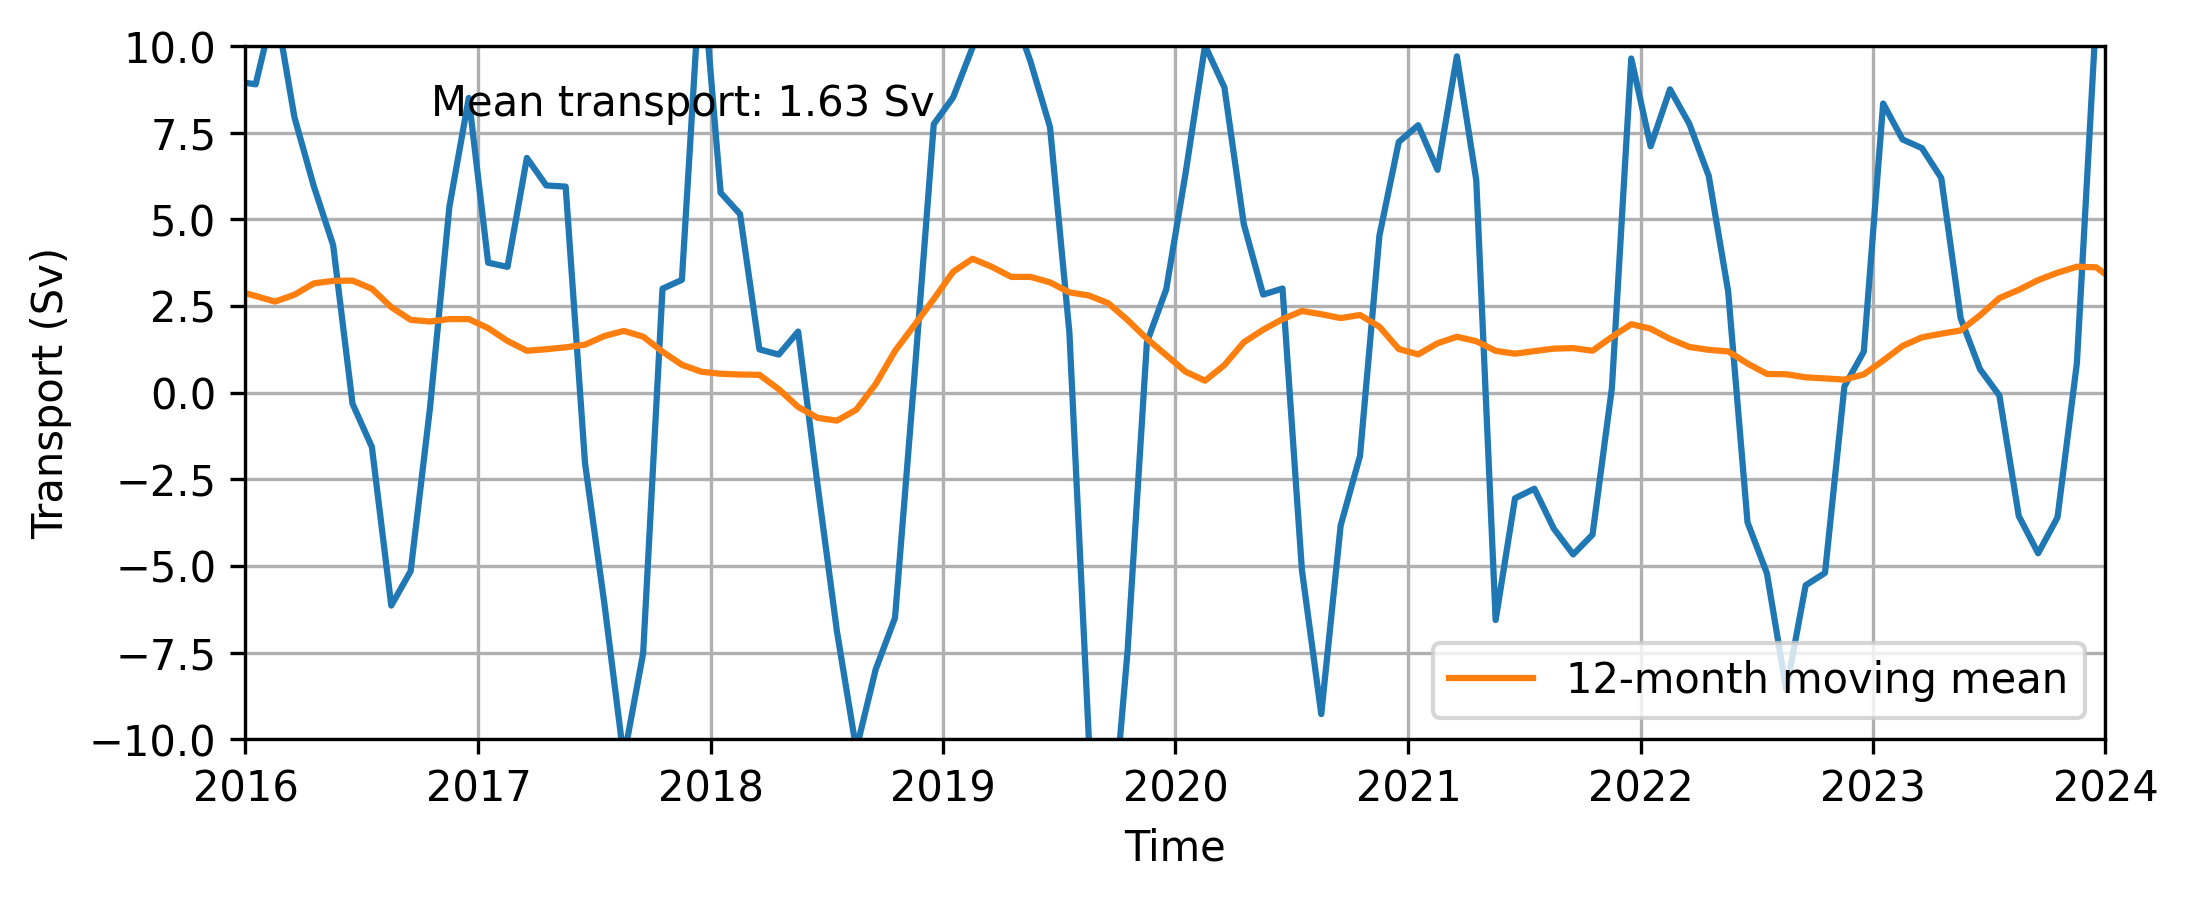

In [3]:
plt.figure(figsize=(8,3),dpi=300)
plt.plot(time,tpgl)
plt.plot(time,tpgl_smooth,label='12-month moving mean')
plt.xlim(np.datetime64('2016-01'),np.datetime64('2024-01'))
plt.xlabel('Time')
plt.ylabel('Transport (Sv)')
plt.grid()
plt.legend()
plt.ylim(-10,10)
plt.text(0.1,0.9,'Mean transport: %.2f Sv'%np.mean(tpgl[26:-10]),transform=plt.gca().transAxes)
# print(time[[26,-10]])